# video 처럼 다루어 보자

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import torch
import tifffile as tiff
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from torchvision import transforms
from sklearn.model_selection import train_test_split
import torch.nn as nn
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import torch.optim as optim
import rasterio
import copy
import torch.nn.init as init

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### train, eval 함수 정의 (Naive ver과 동일)

In [3]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=50, patience=10):
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_model_state = model.state_dict()  # 초기 모델 가중치 저장
    no_improve_count = 0

    for epoch in range(num_epochs):
        # Training Phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training"):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * labels.size(0)  # 배치별 loss * 개수로 전체 손실 계산
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader.dataset)  # 전체 샘플 수로 나눔
        train_accuracy = 100 * correct / total
        train_losses.append(train_loss)

        # Validation Phase
        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Validation"):
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * labels.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_running_loss / len(val_loader.dataset)
        val_accuracy = 100 * val_correct / val_total
        val_losses.append(val_loss)

        print(f"\nEpoch [{epoch+1}/{num_epochs}], "
              f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%, "
              f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%\n")

        # Early Stopping & Model Saving
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            no_improve_count = 0
        else:
            no_improve_count += 1

        if no_improve_count >= patience:
            print("Early stopping triggered. Training stopped.")
            break
    
    return best_model_state, train_losses, val_losses


In [4]:
target_name_mapping = {
    0: "Non-Forest", #비산림
    1: "Pine", #소나무
    2: "Nut Pine", #잣나무
    3: "Larch", #낙엽송
    4: "Pitch Pine", #리기다 소나무
    5: "Oak", #상수리나무
    6: "Mongolian Oak", #신갈나무
    7: "Oriental Oak" #굴참나무
}

def evaluate_model_with_cm(model, val_loader, num_classes=8, target_name_mapping=target_name_mapping):
    model.eval()
    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Evaluation Progress"):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            all_labels.extend(labels.cpu().numpy())  
            all_predictions.extend(predicted.cpu().numpy())  

    # 모든 클래스 목록 (0 ~ num_classes-1)
    full_class_labels = np.arange(num_classes)

    # Confusion Matrix 계산
    cm = confusion_matrix(all_labels, all_predictions, labels=full_class_labels)

    # Confusion Matrix 시각화
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_name_mapping.values(), yticklabels=target_name_mapping.values())
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()
    
    # Classification Report
    target_names = list(target_name_mapping.values())
    report = classification_report(all_labels, all_predictions, labels=full_class_labels, target_names=target_names, digits=3)

    print("Classification Report:")
    print(report)


### Dataset 클래스 정의 (Naive ver과 동일)

In [5]:
class TiffDataset(Dataset):
    def __init__(self, large_tif_dir, file_list, label_file, patch_size=3, box_filter_fn=None, transform=None):
        """
        Args:
            large_tif_dir (str): 여러 개의 큰 TIFF 파일이 저장된 디렉토리 경로.
            file_list (list of str): 처리할 원천 데이터 파일명 리스트.
            label_file (str): 라벨 정보를 담은 CSV 파일 경로 ("file", "x_pos", "y_pos", "label" 열 포함).
            patch_size (int): 슬라이싱할 이미지의 크기 (기본값: 3).
            box_filter_fn (callable, optional): 박스 번호 필터링 함수. 
                - 입력: 박스 번호 (1부터 100까지)
                - 출력: 해당 박스를 사용할지 여부 (True/False).
                - 기본값: None (모든 박스 사용).
            transform (callable, optional): 이미지 전처리에 사용할 함수.
        """
        self.large_tif_dir = large_tif_dir
        self.file_list = set(file_list)
        self.label_df = pd.read_csv(label_file)

        # 박스 필터 함수 설정 (기본값: 모든 박스 사용)
        self.box_filter_fn = box_filter_fn or (lambda box_number: True)

        # 파일명 필터링: file_list에 있는 파일만 유지
        self.label_df = self.label_df[self.label_df['file'].isin(self.file_list)].reset_index(drop=True)

        # 박스 번호 필터링
        self.label_df = self.label_df[self.label_df['box_number'].apply(self.box_filter_fn)].reset_index(drop=True)

        self.patch_size = patch_size
        self.transform = transform

        # 각 파일명을 키로 하고 이미지를 값으로 가지는 딕셔너리
        self.image_cache = {}

    def _load_image(self, file_name):
        """파일 이름에 해당하는 이미지를 로드하여 캐시에 저장."""
        if file_name not in self.image_cache:
            file_path = os.path.join(self.large_tif_dir, file_name)
            if not os.path.exists(file_path):
                raise FileNotFoundError(f"Image file '{file_path}' not found.")
            self.image_cache[file_name] = tiff.imread(file_path)
        return self.image_cache[file_name]

    def __len__(self):
        return len(self.label_df)

    def __getitem__(self, idx):
        # 현재 인덱스에 해당하는 데이터 가져오기
        row = self.label_df.iloc[idx]
        file_name = row["file"]
        x, y = row["x_pos"], row["y_pos"]
        label = row["label"]

        # 이미지 로드
        image = self._load_image(file_name)
        image_height, image_width = image.shape[:2]

        # 범위 검사
        if x < 0 or y < 0 or x + self.patch_size > image_width or y + self.patch_size > image_height:
            raise ValueError(f"Patch at position (x={x}, y={y}) exceeds bounds of image '{file_name}'.")

        # 이미지 슬라이싱
        patch = image[y:y + self.patch_size, x:x + self.patch_size]
        # 전처리 적용
        if self.transform:
            patch = self.transform(patch)

        return patch, label


### 테스트지역 선별 (Naive ver과 동의)

In [6]:
# 테스트 필터 정의
test_filter = lambda box_number: (box_number % 9 == 0 or box_number % 9 == 5)

### 데이터 전처리 방법 설정 - 우선 가장 간단하게

In [7]:
class ReshapeTransform:
    """(12*bands, 3, 3) → (12, bands, 3, 3) 변환"""
    def __init__(self, bands):
        self.bands = bands

    def __call__(self, x):
        return x.view(12, self.bands, 3, 3)

def get_transform(bands):
    return transforms.Compose([
        transforms.ToTensor(),  # (H, W, C) → (C, H, W)
        transforms.Lambda(lambda x: x.float()),  # uint16 → float 변환
        ReshapeTransform(bands),  # (12*bands, 3, 3) → (12, bands, 3, 3)
    ])

### 3D CNN과 2+1D Conv, Attention Mechanism을 조합한 모델

In [8]:
class TemporalAttention(nn.Module):
    def __init__(self, in_channels, num_frames):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Conv3d(in_channels, in_channels // 2, kernel_size=1),
            nn.ReLU(),
            nn.Conv3d(in_channels // 2, 1, kernel_size=1)  # 1개의 attention map 생성
        )
        self.softmax = nn.Softmax(dim=2)  # Temporal axis (T)에 대해 softmax 적용

    def forward(self, x):
        attn_weights = self.softmax(self.attn(x))  # (B, 1, 12, H, W)
        return x * attn_weights  # (B, C, 12, H, W) * (B, 1, 12, H, W)


class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3):
        super().__init__()
        padding = kernel_size // 2
        self.conv1 = nn.Conv3d(in_channels, out_channels, kernel_size, padding=padding)
        self.bn1 = nn.BatchNorm3d(out_channels)
        self.conv2 = nn.Conv3d(out_channels, out_channels, kernel_size, padding=padding)
        self.bn2 = nn.BatchNorm3d(out_channels)
        self.skip = nn.Conv3d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else nn.Identity()

    def forward(self, x):
        identity = self.skip(x)
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        return F.relu(x + identity)

class TreeSpeciesClassifier(nn.Module):
    def __init__(self, bands, num_classes=8):
        super().__init__()
        self.input_channels = bands
        self.conv1 = nn.Conv3d(12, 32, kernel_size=(3, 3, 3), padding=1)  # (T, C, H, W) -> (32, H, W)
        self.res_block1 = ResidualBlock(32, 64)
        self.res_block2 = ResidualBlock(64, 128)
        self.attn = TemporalAttention(128, 12)
        self.pool = nn.AdaptiveAvgPool3d((1, 1, 1))
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = x.view(-1, 12, self.input_channels, 3, 3)  # Reshape to (B, T, C, H, W)
        x = self.conv1(x)
        x = self.res_block1(x)
        x = self.res_block2(x)
        x = self.attn(x)
        x = self.pool(x).view(x.shape[0], -1)
        return self.fc(x)

### Xavier He 초기화 사용

In [9]:
def init_weights(m):
    if isinstance(m, nn.Linear) or isinstance(m, nn.Conv2d) or isinstance(m, nn.Conv3d):
        init.xavier_uniform_(m.weight)  # Xavier He 초기화 적용
        if m.bias is not None:
            init.zeros_(m.bias)  # Bias는 0으로 초기화

## B, G, R, NIR 사용

In [10]:
large_tif_dir = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\원천 데이터\naive" #원천데이터 주소
bands = 4 #밴드 수

transform = get_transform(bands)

train_dataset = TiffDataset(
    large_tif_dir = large_tif_dir,
    file_list = ["jiri_1.tif", "jiri_2.tif", "sobaek.tif"], #전체 지역을 모두 사용한다.
    label_file = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\라벨링 데이터\label_mapping_sampled.csv",
    box_filter_fn = lambda box_number: not test_filter(box_number),
    transform=transform
)

val_dataset = TiffDataset(
    large_tif_dir = large_tif_dir,
    file_list = ["jiri_1.tif", "jiri_2.tif", "sobaek.tif"], #전체 지역을 모두 사용한다.
    label_file = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\라벨링 데이터\label_mapping_sampled.csv",
    box_filter_fn = test_filter,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)

In [11]:
model = TreeSpeciesClassifier(bands=bands , num_classes=8).to(device)
model.apply(init_weights)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

### 모델 학습

In [12]:
best_model_state, train_losses, val_losses = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=15, patience=100)
model.load_state_dict(best_model_state)
torch.save(best_model_state, "./video_15.pth")

Epoch 1/15 - Validation: 100%|██████████| 1169/1169 [00:20<00:00, 55.74it/s]



Epoch [1/15], Train Loss: 1.2588, Train Accuracy: 69.90%, Val Loss: 0.7899, Val Accuracy: 71.67%



Epoch 2/15 - Validation: 100%|██████████| 1169/1169 [00:23<00:00, 49.06it/s]



Epoch [2/15], Train Loss: 0.5414, Train Accuracy: 80.66%, Val Loss: 0.5684, Val Accuracy: 78.99%



Epoch 3/15 - Validation: 100%|██████████| 1169/1169 [00:22<00:00, 51.66it/s]


...


Epoch [13/15], Train Loss: 0.3028, Train Accuracy: 88.90%, Val Loss: 0.4878, Val Accuracy: 83.46%



Epoch 14/15 - Validation: 100%|██████████| 1169/1169 [00:21<00:00, 54.32it/s]



Epoch [14/15], Train Loss: 0.2982, Train Accuracy: 89.12%, Val Loss: 0.4938, Val Accuracy: 84.18%



Epoch 15/15 - Validation: 100%|██████████| 1169/1169 [00:23<00:00, 49.96it/s]


Epoch [15/15], Train Loss: 0.2987, Train Accuracy: 89.38%, Val Loss: 0.5200, Val Accuracy: 84.07%



### 모델 테스트

train data

Evaluation Progress: 100%|██████████| 3733/3733 [01:09<00:00, 53.74it/s]


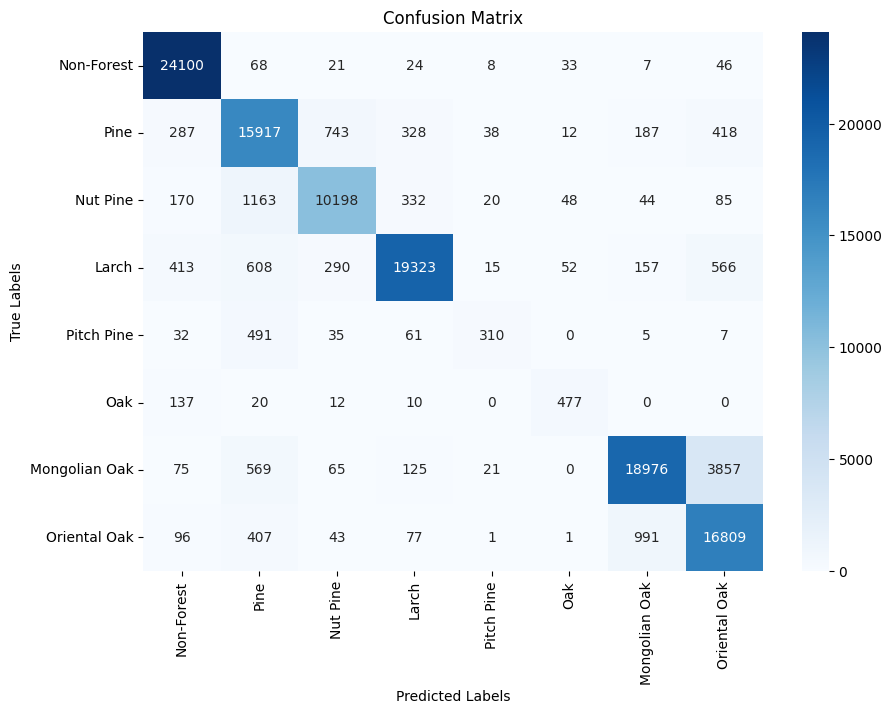

Classification Report:
               precision    recall  f1-score   support

   Non-Forest      0.952     0.991     0.971     24307
         Pine      0.827     0.888     0.856     17930
     Nut Pine      0.894     0.846     0.869     12060
        Larch      0.953     0.902     0.927     21424
   Pitch Pine      0.751     0.329     0.458       941
          Oak      0.766     0.727     0.746       656
Mongolian Oak      0.932     0.801     0.861     23688
 Oriental Oak      0.771     0.912     0.836     18425

     accuracy                          0.888    119431
    macro avg      0.856     0.800     0.816    119431
 weighted avg      0.893     0.888     0.888    119431



In [13]:
evaluate_model_with_cm(model, train_loader, num_classes=8)

validation data

Evaluation Progress: 100%|██████████| 1169/1169 [00:21<00:00, 53.75it/s]


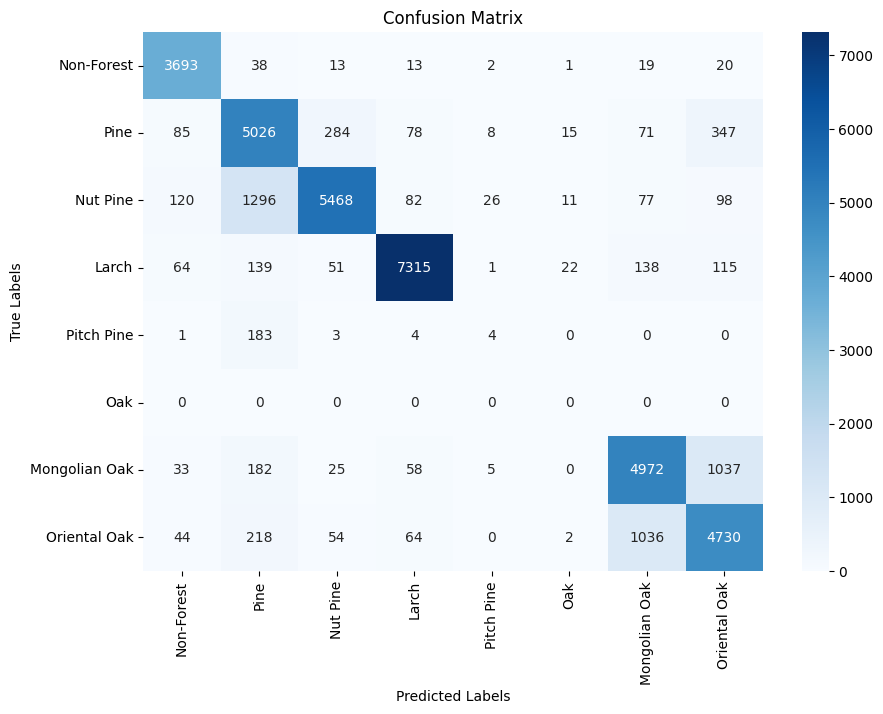

Classification Report:
               precision    recall  f1-score   support

   Non-Forest      0.914     0.972     0.942      3799
         Pine      0.710     0.850     0.773      5914
     Nut Pine      0.927     0.762     0.836      7178
        Larch      0.961     0.932     0.946      7845
   Pitch Pine      0.087     0.021     0.033       195
          Oak      0.000     0.000     0.000         0
Mongolian Oak      0.788     0.788     0.788      6312
 Oriental Oak      0.745     0.769     0.757      6148

     accuracy                          0.835     37391
    macro avg      0.641     0.637     0.635     37391
 weighted avg      0.841     0.835     0.835     37391



c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [14]:
evaluate_model_with_cm(model, val_loader, num_classes=8)

## NDVI 추가

In [10]:
large_tif_dir = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\원천 데이터\with_ndvi" #원천데이터 주소
bands = 5 #밴드 수

transform = get_transform(bands)

train_dataset = TiffDataset(
    large_tif_dir = large_tif_dir,
    file_list = ["jiri_1.tif", "jiri_2.tif", "sobaek.tif"], #전체 지역을 모두 사용한다.
    label_file = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\라벨링 데이터\label_mapping_sampled.csv",
    box_filter_fn = lambda box_number: not test_filter(box_number),
    transform=transform
)

val_dataset = TiffDataset(
    large_tif_dir = large_tif_dir,
    file_list = ["jiri_1.tif", "jiri_2.tif", "sobaek.tif"], #전체 지역을 모두 사용한다.
    label_file = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\라벨링 데이터\label_mapping_sampled.csv",
    box_filter_fn = test_filter,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)

In [11]:
model = TreeSpeciesClassifier(bands=bands , num_classes=8).to(device)
model.apply(init_weights)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

### 모델 학습

In [12]:
best_model_state, train_losses, val_losses = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=15, patience=100)
model.load_state_dict(best_model_state)
torch.save(best_model_state, "./video_with_ndvi_15.pth")

Epoch 1/15 - Training:   0%|          | 0/3733 [00:00<?, ?it/s]

Epoch 1/15 - Validation: 100%|██████████| 1169/1169 [00:35<00:00, 32.74it/s]



Epoch [1/15], Train Loss: 0.6449, Train Accuracy: 76.91%, Val Loss: 0.6024, Val Accuracy: 77.61%



Epoch 2/15 - Validation: 100%|██████████| 1169/1169 [00:29<00:00, 39.14it/s]



Epoch [2/15], Train Loss: 0.5266, Train Accuracy: 81.06%, Val Loss: 0.6278, Val Accuracy: 78.72%



...


Epoch [13/15], Train Loss: 0.3110, Train Accuracy: 88.62%, Val Loss: 0.5772, Val Accuracy: 81.65%



Epoch 14/15 - Validation: 100%|██████████| 1169/1169 [00:23<00:00, 50.74it/s]



Epoch [14/15], Train Loss: 0.3132, Train Accuracy: 88.82%, Val Loss: 0.5357, Val Accuracy: 83.72%



Epoch 15/15 - Validation: 100%|██████████| 1169/1169 [00:22<00:00, 50.84it/s]


Epoch [15/15], Train Loss: 0.3100, Train Accuracy: 88.94%, Val Loss: 0.6075, Val Accuracy: 80.82%



### 모델 테스트

train data

Evaluation Progress: 100%|██████████| 3733/3733 [01:12<00:00, 51.29it/s]


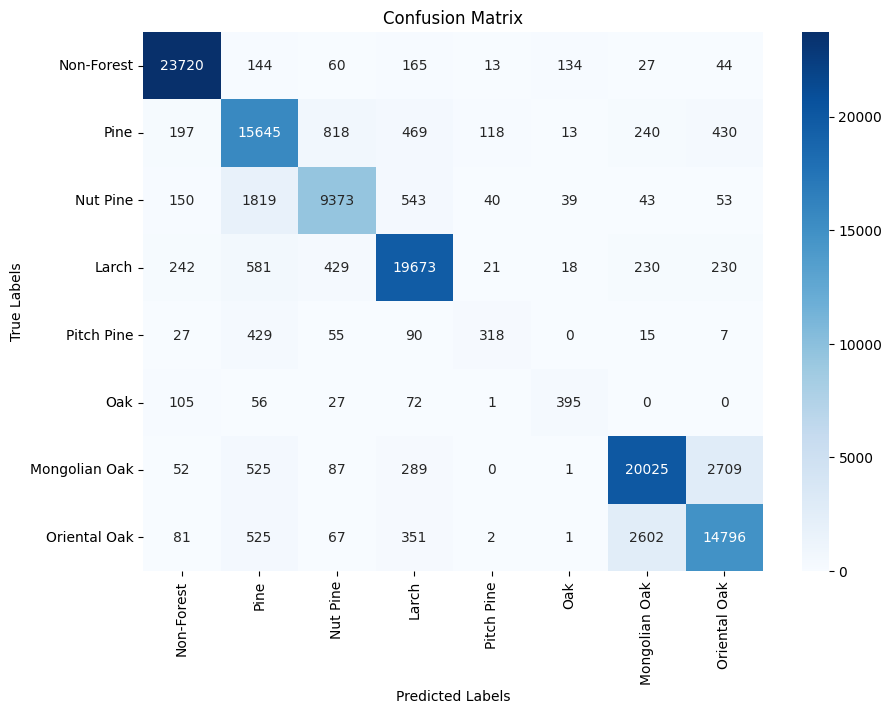

Classification Report:
               precision    recall  f1-score   support

   Non-Forest      0.965     0.976     0.971     24307
         Pine      0.793     0.873     0.831     17930
     Nut Pine      0.859     0.777     0.816     12060
        Larch      0.909     0.918     0.913     21424
   Pitch Pine      0.620     0.338     0.437       941
          Oak      0.657     0.602     0.628       656
Mongolian Oak      0.864     0.845     0.854     23688
 Oriental Oak      0.810     0.803     0.806     18425

     accuracy                          0.870    119431
    macro avg      0.810     0.767     0.782    119431
 weighted avg      0.870     0.870     0.869    119431



In [13]:
evaluate_model_with_cm(model, train_loader, num_classes=8)

validation data

Evaluation Progress: 100%|██████████| 1169/1169 [00:22<00:00, 51.34it/s]


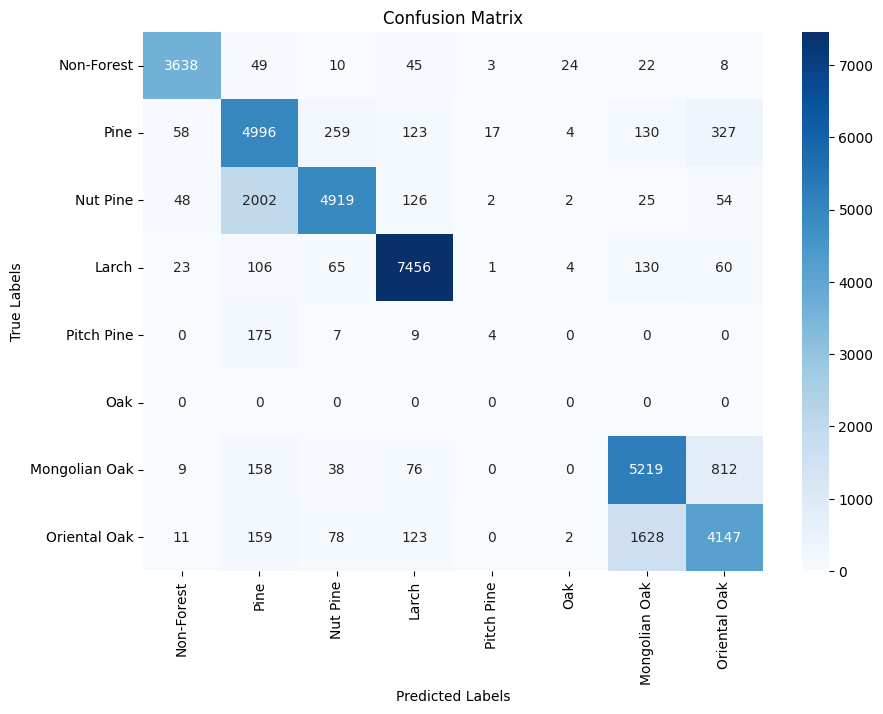

Classification Report:
               precision    recall  f1-score   support

   Non-Forest      0.961     0.958     0.959      3799
         Pine      0.653     0.845     0.737      5914
     Nut Pine      0.915     0.685     0.784      7178
        Larch      0.937     0.950     0.944      7845
   Pitch Pine      0.148     0.021     0.036       195
          Oak      0.000     0.000     0.000         0
Mongolian Oak      0.730     0.827     0.775      6312
 Oriental Oak      0.767     0.675     0.718      6148

     accuracy                          0.812     37391
    macro avg      0.639     0.620     0.619     37391
 weighted avg      0.823     0.812     0.811     37391



c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [14]:
evaluate_model_with_cm(model, val_loader, num_classes=8)

## NDVI, Sentinel_2(B05, B06, B07, B11, B12) 데이터 추가

In [15]:
large_tif_dir = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\원천 데이터\with_ndvi_s2" #원천데이터 주소
bands = 10 #밴드 수

transform = get_transform(bands)

train_dataset = TiffDataset(
    large_tif_dir = large_tif_dir,
    file_list = ["jiri_1.tif", "jiri_2.tif", "sobaek.tif"], #전체 지역을 모두 사용한다.
    label_file = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\라벨링 데이터\label_mapping_sampled.csv",
    box_filter_fn = lambda box_number: not test_filter(box_number),
    transform=transform
)

val_dataset = TiffDataset(
    large_tif_dir = large_tif_dir,
    file_list = ["jiri_1.tif", "jiri_2.tif", "sobaek.tif"], #전체 지역을 모두 사용한다.
    label_file = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\라벨링 데이터\label_mapping_sampled.csv",
    box_filter_fn = test_filter,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)

In [16]:
model = TreeSpeciesClassifier(bands=bands , num_classes=8).to(device)
model.apply(init_weights)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

### 모델 학습

In [17]:
best_model_state, train_losses, val_losses = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=15, patience=100)
model.load_state_dict(best_model_state)
torch.save(best_model_state, "./video_with_ndvi_s2_15.pth")

Epoch 1/15 - Validation: 100%|██████████| 1169/1169 [00:55<00:00, 21.01it/s]



Epoch [1/15], Train Loss: 1.6806, Train Accuracy: 66.27%, Val Loss: 0.8608, Val Accuracy: 63.26%



Epoch 2/15 - Validation: 100%|██████████| 1169/1169 [00:36<00:00, 31.95it/s]



Epoch [2/15], Train Loss: 0.6748, Train Accuracy: 74.46%, Val Loss: 0.7351, Val Accuracy: 71.39%



Epoch 3/15 - Validation: 100%|██████████| 1169/1169 [00:43<00:00, 26.81it/s]


...


Epoch [13/15], Train Loss: 0.4364, Train Accuracy: 84.83%, Val Loss: 0.6064, Val Accuracy: 80.17%



Epoch 14/15 - Validation: 100%|██████████| 1169/1169 [00:39<00:00, 29.51it/s]



Epoch [14/15], Train Loss: 0.3742, Train Accuracy: 86.46%, Val Loss: 0.5557, Val Accuracy: 82.07%



Epoch 15/15 - Validation: 100%|██████████| 1169/1169 [00:38<00:00, 30.25it/s]


Epoch [15/15], Train Loss: 0.4682, Train Accuracy: 85.90%, Val Loss: 0.7014, Val Accuracy: 75.59%



### 모델 테스트

train data

Evaluation Progress: 100%|██████████| 3733/3733 [01:54<00:00, 32.68it/s]


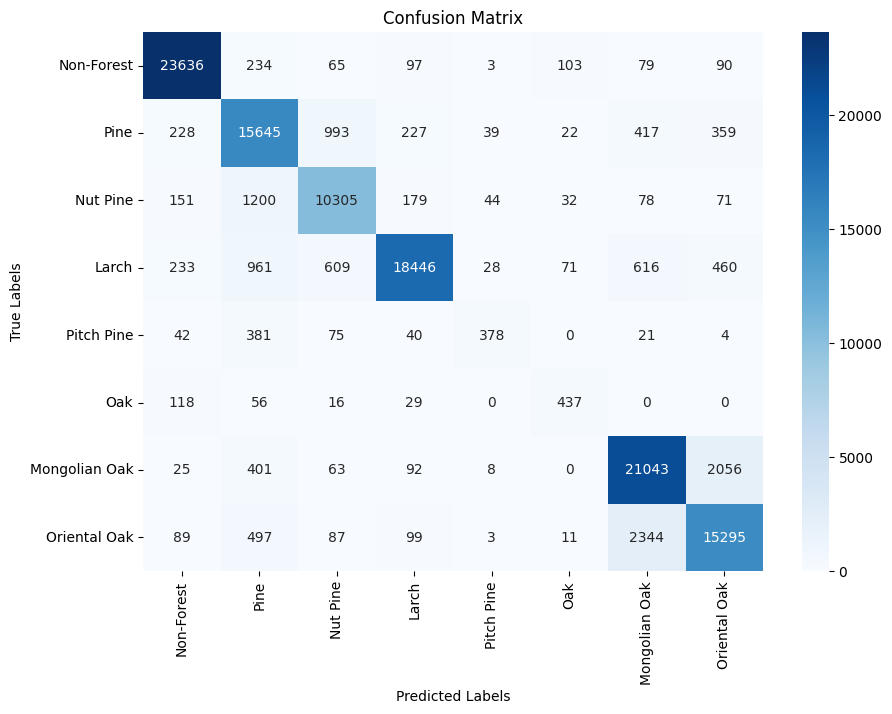

Classification Report:
               precision    recall  f1-score   support

   Non-Forest      0.964     0.972     0.968     24307
         Pine      0.807     0.873     0.839     17930
     Nut Pine      0.844     0.854     0.849     12060
        Larch      0.960     0.861     0.908     21424
   Pitch Pine      0.751     0.402     0.524       941
          Oak      0.646     0.666     0.656       656
Mongolian Oak      0.855     0.888     0.872     23688
 Oriental Oak      0.834     0.830     0.832     18425

     accuracy                          0.881    119431
    macro avg      0.833     0.793     0.806    119431
 weighted avg      0.883     0.881     0.881    119431



In [18]:
evaluate_model_with_cm(model, train_loader, num_classes=8)

val data

Evaluation Progress: 100%|██████████| 1169/1169 [00:35<00:00, 32.71it/s]


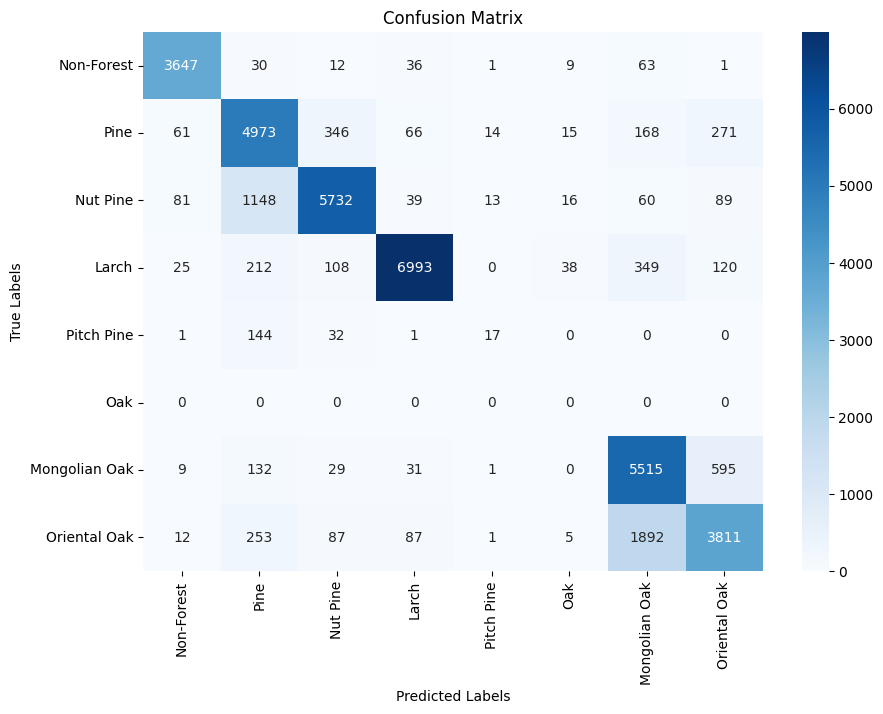

Classification Report:
               precision    recall  f1-score   support

   Non-Forest      0.951     0.960     0.955      3799
         Pine      0.722     0.841     0.777      5914
     Nut Pine      0.903     0.799     0.848      7178
        Larch      0.964     0.891     0.926      7845
   Pitch Pine      0.362     0.087     0.140       195
          Oak      0.000     0.000     0.000         0
Mongolian Oak      0.685     0.874     0.768      6312
 Oriental Oak      0.780     0.620     0.691      6148

     accuracy                          0.821     37391
    macro avg      0.671     0.634     0.638     37391
 weighted avg      0.832     0.821     0.821     37391



c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [19]:
evaluate_model_with_cm(model, val_loader, num_classes=8)

## 왜 NDVI가 도움이 안될까? NDVI만을 이용해보자

In [20]:
large_tif_dir = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\원천 데이터\ndvi_only" #원천데이터 주소
bands = 1 #밴드 수

transform = get_transform(bands)

train_dataset = TiffDataset(
    large_tif_dir = large_tif_dir,
    file_list = ["jiri_1.tif", "jiri_2.tif", "sobaek.tif"], #전체 지역을 모두 사용한다.
    label_file = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\라벨링 데이터\label_mapping_sampled.csv",
    box_filter_fn = lambda box_number: not test_filter(box_number),
    transform=transform
)

val_dataset = TiffDataset(
    large_tif_dir = large_tif_dir,
    file_list = ["jiri_1.tif", "jiri_2.tif", "sobaek.tif"], #전체 지역을 모두 사용한다.
    label_file = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\라벨링 데이터\label_mapping_sampled.csv",
    box_filter_fn = test_filter,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [21]:
model = TreeSpeciesClassifier(bands=bands , num_classes=8).to(device)
model.apply(init_weights)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

### 모델 학습

In [22]:
best_model_state, train_losses, val_losses = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=15, patience=100)
torch.save(best_model_state, './video_ndvi only_15.pth')
model.load_state_dict(best_model_state)

Epoch 1/15 - Validation: 100%|██████████| 1169/1169 [00:14<00:00, 78.14it/s]



Epoch [1/15], Train Loss: 6.4572, Train Accuracy: 55.83%, Val Loss: 1.4827, Val Accuracy: 50.42%



Epoch 2/15 - Validation: 100%|██████████| 1169/1169 [00:12<00:00, 90.45it/s]



Epoch [2/15], Train Loss: 0.9649, Train Accuracy: 64.28%, Val Loss: 3.5148, Val Accuracy: 10.20%



Epoch 3/15 - Validation: 100%|██████████| 1169/1169 [00:13<00:00, 89.89it/s]


...

Epoch 14/15 - Validation: 100%|██████████| 1169/1169 [00:13<00:00, 88.62it/s]



Epoch [14/15], Train Loss: 1.8250, Train Accuracy: 20.29%, Val Loss: 2850.6453, Val Accuracy: 10.15%



Epoch 15/15 - Validation: 100%|██████████| 1169/1169 [00:12<00:00, 90.01it/s]


Epoch [15/15], Train Loss: 1.8249, Train Accuracy: 20.14%, Val Loss: 2749.9686, Val Accuracy: 16.88%



<All keys matched successfully>

### 모델 테스트

Evaluation Progress: 100%|██████████| 3733/3733 [00:40<00:00, 91.30it/s]


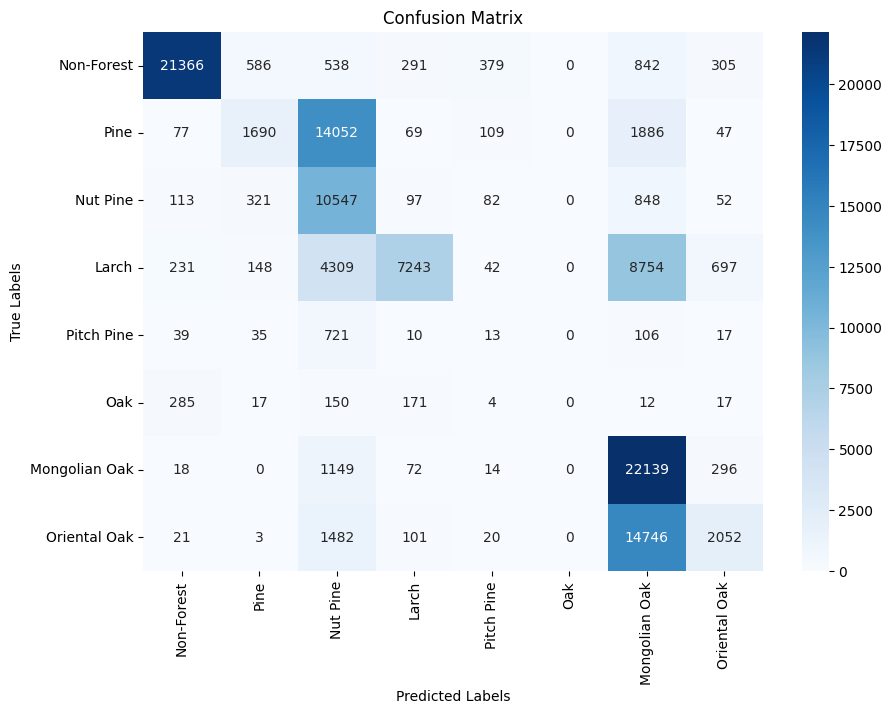

Classification Report:
               precision    recall  f1-score   support

   Non-Forest      0.965     0.879     0.920     24307
         Pine      0.604     0.094     0.163     17930
     Nut Pine      0.320     0.875     0.469     12060
        Larch      0.899     0.338     0.491     21424
   Pitch Pine      0.020     0.014     0.016       941
          Oak      0.000     0.000     0.000       656
Mongolian Oak      0.449     0.935     0.606     23688
 Oriental Oak      0.589     0.111     0.187     18425

     accuracy                          0.545    119431
    macro avg      0.481     0.406     0.357    119431
 weighted avg      0.661     0.545     0.496    119431



c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [23]:
evaluate_model_with_cm(model, train_loader, num_classes=8)

validation data

Evaluation Progress: 100%|██████████| 1169/1169 [00:12<00:00, 91.54it/s]


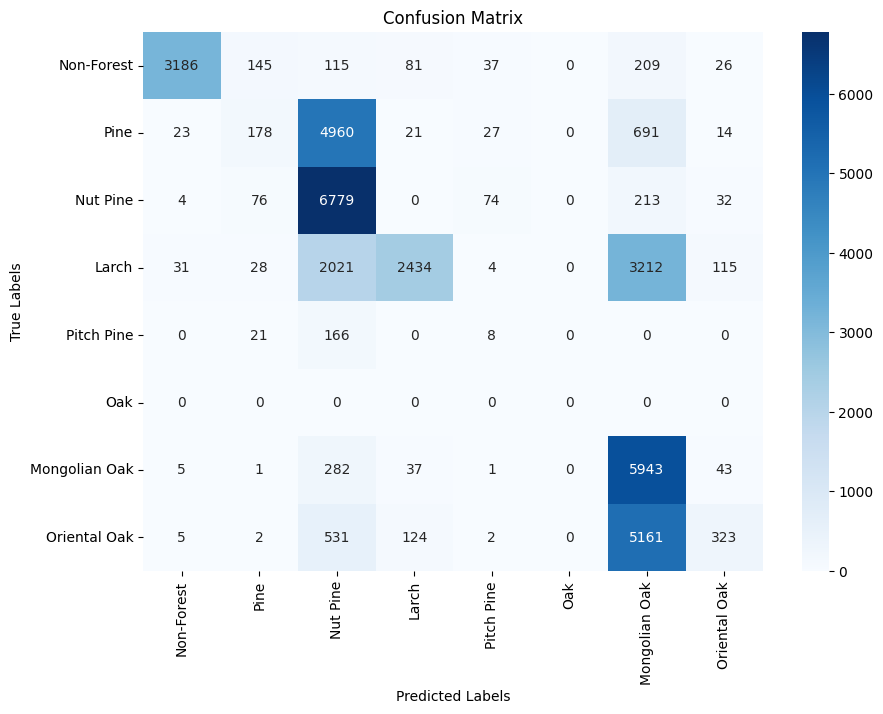

Classification Report:
               precision    recall  f1-score   support

   Non-Forest      0.979     0.839     0.903      3799
         Pine      0.395     0.030     0.056      5914
     Nut Pine      0.456     0.944     0.615      7178
        Larch      0.902     0.310     0.462      7845
   Pitch Pine      0.052     0.041     0.046       195
          Oak      0.000     0.000     0.000         0
Mongolian Oak      0.385     0.942     0.547      6312
 Oriental Oak      0.584     0.053     0.096      6148

     accuracy                          0.504     37391
    macro avg      0.469     0.395     0.341     37391
 weighted avg      0.600     0.504     0.424     37391



c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\taebin\anaconda3\Lib\site-pac

In [24]:
evaluate_model_with_cm(model, val_loader, num_classes=8)

## band별로 크기가 너무 달라서 그럴 수 도 있다. - min max scaling을 적용

In [25]:
import torch
from torchvision import transforms

class BandwiseMinMax:
    """각 밴드별 Min-Max Scaling"""
    def __init__(self, min_val, max_val):
        self.min_val = torch.tensor(min_val, dtype=torch.float32).view(1, -1, 1, 1)
        self.max_val = torch.tensor(max_val, dtype=torch.float32).view(1, -1, 1, 1)

    def __call__(self, x):
        return (x - self.min_val) / (self.max_val - self.min_val + 1e-6)  # 0으로 나누는 문제 방지

def get_transform_minmax(bands, min_val, max_val):
    """Min-Max Scaling을 적용한 변환"""
    return transforms.Compose([
        transforms.ToTensor(),  # (H, W, C) → (C, H, W)
        transforms.Lambda(lambda x: x.float()),  # uint16 → float 변환
        ReshapeTransform(bands),  # (12*bands, 3, 3) → (12, bands, 3, 3)
        BandwiseMinMax(min_val, max_val)  # Min-Max Scaling 적용
    ])


In [26]:
large_tif_dir = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\원천 데이터\with_ndvi" #원천데이터 주소
bands = 5 #밴드 수

# 파일 경로 리스트
file_paths = [
    f"{large_tif_dir}/sobaek.tif",
    f"{large_tif_dir}/jiri_1.tif",
    f"{large_tif_dir}/jiri_2.tif"
]

# 각 데이터셋의 min, max 값을 저장할 리스트
min_vals, max_vals = [], []

# 데이터 로드 및 최소/최대값 계산
for path in file_paths:
    with rasterio.open(path) as src:
        data = src.read().reshape(12, -1, 3000, 3000)
        min_vals.append(data.min(axis=(0, 2, 3)))  # (bands,)
        max_vals.append(data.max(axis=(0, 2, 3)))  # (bands,)

# 전체 min/max 계산
global_min = np.min(np.stack(min_vals), axis=0)
global_max = np.max(np.stack(max_vals), axis=0)

print("Global Min per band:", global_min)
print("Global Max per band:", global_max)

transform = get_transform_minmax(bands=bands, min_val=global_min, max_val=global_max)

train_dataset = TiffDataset(
    large_tif_dir = large_tif_dir,
    file_list = ["jiri_1.tif", "jiri_2.tif", "sobaek.tif"], #전체 지역을 모두 사용한다.
    label_file = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\라벨링 데이터\label_mapping_sampled.csv",
    box_filter_fn = lambda box_number: not test_filter(box_number),
    transform=transform
)

val_dataset = TiffDataset(
    large_tif_dir = large_tif_dir,
    file_list = ["jiri_1.tif", "jiri_2.tif", "sobaek.tif"], #전체 지역을 모두 사용한다.
    label_file = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\라벨링 데이터\label_mapping_sampled.csv",
    box_filter_fn = test_filter,
    transform=transform
)

Global Min per band: [1 1 4 3 7]
Global Max per band: [ 7759  7994 10398 20987 65498]


In [27]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)
model = TreeSpeciesClassifier(bands=bands , num_classes=8).to(device)
model.apply(init_weights)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [28]:
best_model_state, train_losses, val_losses = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=15, patience=100)
model.load_state_dict(best_model_state)
torch.save(best_model_state, "./video_minmax_with_ndvi_15.pth")

Epoch 1/15 - Validation: 100%|██████████| 1169/1169 [00:28<00:00, 41.63it/s]



Epoch [1/15], Train Loss: 0.5422, Train Accuracy: 79.93%, Val Loss: 0.6389, Val Accuracy: 77.36%



Epoch 2/15 - Validation: 100%|██████████| 1169/1169 [00:29<00:00, 40.27it/s]



Epoch [2/15], Train Loss: 0.4080, Train Accuracy: 85.05%, Val Loss: 0.4915, Val Accuracy: 82.63%



Epoch 3/15 - Validation: 100%|██████████| 1169/1169 [00:25<00:00, 45.62it/s]


...


Epoch [13/15], Train Loss: 0.1932, Train Accuracy: 92.88%, Val Loss: 0.6009, Val Accuracy: 83.44%



Epoch 14/15 - Validation: 100%|██████████| 1169/1169 [00:25<00:00, 45.37it/s]



Epoch [14/15], Train Loss: 0.1858, Train Accuracy: 93.06%, Val Loss: 0.6471, Val Accuracy: 84.02%



Epoch 15/15 - Validation: 100%|██████████| 1169/1169 [00:25<00:00, 44.97it/s]


Epoch [15/15], Train Loss: 0.1799, Train Accuracy: 93.35%, Val Loss: 0.6849, Val Accuracy: 83.52%



Evaluation Progress: 100%|██████████| 3733/3733 [01:20<00:00, 46.41it/s]


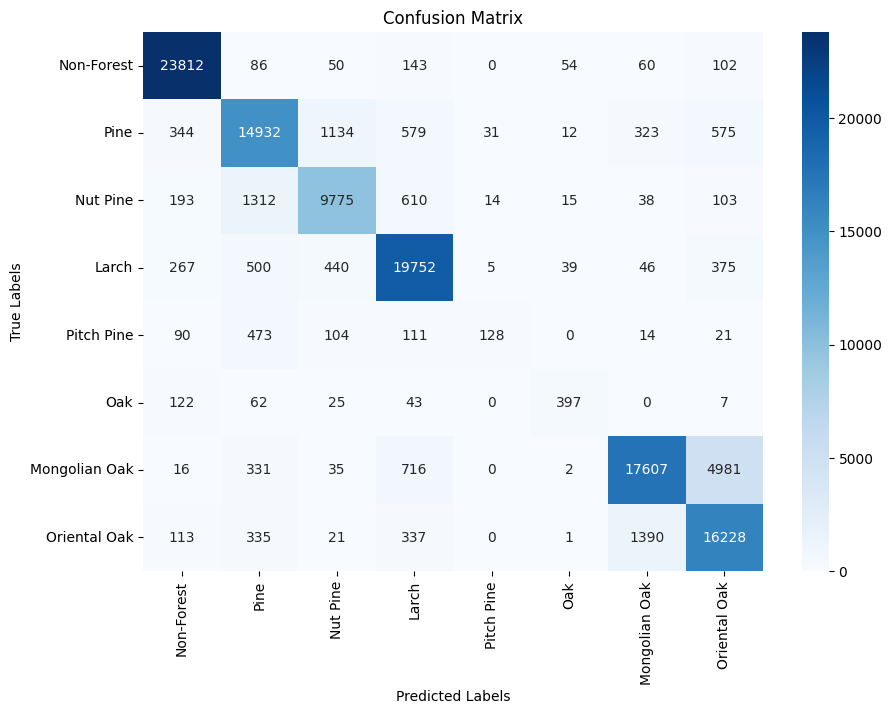

Classification Report:
               precision    recall  f1-score   support

   Non-Forest      0.954     0.980     0.967     24307
         Pine      0.828     0.833     0.830     17930
     Nut Pine      0.844     0.811     0.827     12060
        Larch      0.886     0.922     0.904     21424
   Pitch Pine      0.719     0.136     0.229       941
          Oak      0.763     0.605     0.675       656
Mongolian Oak      0.904     0.743     0.816     23688
 Oriental Oak      0.725     0.881     0.795     18425

     accuracy                          0.859    119431
    macro avg      0.828     0.739     0.755    119431
 weighted avg      0.864     0.859     0.857    119431



In [29]:
evaluate_model_with_cm(model, train_loader, num_classes=8)

Evaluation Progress: 100%|██████████| 1169/1169 [00:25<00:00, 46.23it/s]


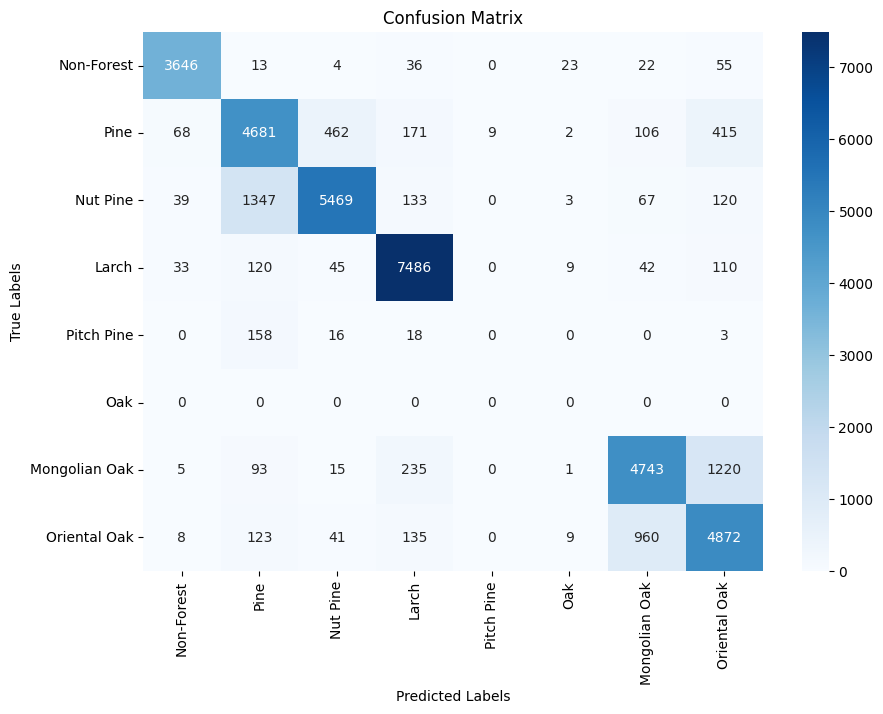

Classification Report:
               precision    recall  f1-score   support

   Non-Forest      0.960     0.960     0.960      3799
         Pine      0.716     0.792     0.752      5914
     Nut Pine      0.904     0.762     0.827      7178
        Larch      0.911     0.954     0.932      7845
   Pitch Pine      0.000     0.000     0.000       195
          Oak      0.000     0.000     0.000         0
Mongolian Oak      0.798     0.751     0.774      6312
 Oriental Oak      0.717     0.792     0.753      6148

     accuracy                          0.826     37391
    macro avg      0.626     0.626     0.625     37391
 weighted avg      0.828     0.826     0.825     37391



c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [30]:
evaluate_model_with_cm(model, val_loader, num_classes=8)

In [31]:
large_tif_dir = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\원천 데이터\with_ndvi_s2" #원천데이터 주소
bands = 10 #밴드 수

# 파일 경로 리스트
file_paths = [
    f"{large_tif_dir}/sobaek.tif",
    f"{large_tif_dir}/jiri_1.tif",
    f"{large_tif_dir}/jiri_2.tif"
]

# 각 데이터셋의 min, max 값을 저장할 리스트
min_vals, max_vals = [], []

# 데이터 로드 및 최소/최대값 계산
for path in file_paths:
    with rasterio.open(path) as src:
        data = src.read().reshape(12, -1, 3000, 3000)
        min_vals.append(data.min(axis=(0, 2, 3)))  # (bands,)
        max_vals.append(data.max(axis=(0, 2, 3)))  # (bands,)

# 전체 min/max 계산
global_min = np.min(np.stack(min_vals), axis=0)
global_max = np.max(np.stack(max_vals), axis=0)

print("Global Min per band:", global_min)
print("Global Max per band:", global_max)

transform = get_transform_minmax(bands=bands, min_val=global_min, max_val=global_max)

train_dataset = TiffDataset(
    large_tif_dir = large_tif_dir,
    file_list = ["jiri_1.tif", "jiri_2.tif", "sobaek.tif"], #전체 지역을 모두 사용한다.
    label_file = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\라벨링 데이터\label_mapping_sampled.csv",
    box_filter_fn = lambda box_number: not test_filter(box_number),
    transform=transform
)

val_dataset = TiffDataset(
    large_tif_dir = large_tif_dir,
    file_list = ["jiri_1.tif", "jiri_2.tif", "sobaek.tif"], #전체 지역을 모두 사용한다.
    label_file = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\라벨링 데이터\label_mapping_sampled.csv",
    box_filter_fn = test_filter,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)

Global Min per band: [ 1  1  4  3 16  0  0  0  0  0]
Global Max per band: [ 7759  7994 10398 20987 65522 13529 12814 12541 10244  9826]


In [32]:
model = TreeSpeciesClassifier(bands=bands , num_classes=8).to(device)
model.apply(init_weights)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [33]:
best_model_state, train_losses, val_losses = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=15, patience=100)
model.load_state_dict(best_model_state)
torch.save(best_model_state, "./video_minmax_with_ndvi_s2_15.pth")

Epoch 1/15 - Validation: 100%|██████████| 1169/1169 [01:27<00:00, 13.32it/s]



Epoch [1/15], Train Loss: 0.6122, Train Accuracy: 76.87%, Val Loss: 1.7318, Val Accuracy: 45.78%



Epoch 2/15 - Validation: 100%|██████████| 1169/1169 [00:39<00:00, 29.51it/s]



Epoch [2/15], Train Loss: 0.4563, Train Accuracy: 82.92%, Val Loss: 0.9351, Val Accuracy: 66.49%



Epoch 3/15 - Validation: 100%|██████████| 1169/1169 [00:39<00:00, 29.62it/s]


...


Epoch [13/15], Train Loss: 0.1772, Train Accuracy: 93.55%, Val Loss: 0.8967, Val Accuracy: 79.82%



Epoch 14/15 - Validation: 100%|██████████| 1169/1169 [00:40<00:00, 28.89it/s]



Epoch [14/15], Train Loss: 0.1696, Train Accuracy: 93.82%, Val Loss: 0.8965, Val Accuracy: 78.78%



Epoch 15/15 - Validation: 100%|██████████| 1169/1169 [00:39<00:00, 29.68it/s]



Epoch [15/15], Train Loss: 0.1597, Train Accuracy: 94.19%, Val Loss: 0.7560, Val Accuracy: 81.86%



Evaluation Progress: 100%|██████████| 3733/3733 [02:02<00:00, 30.48it/s]


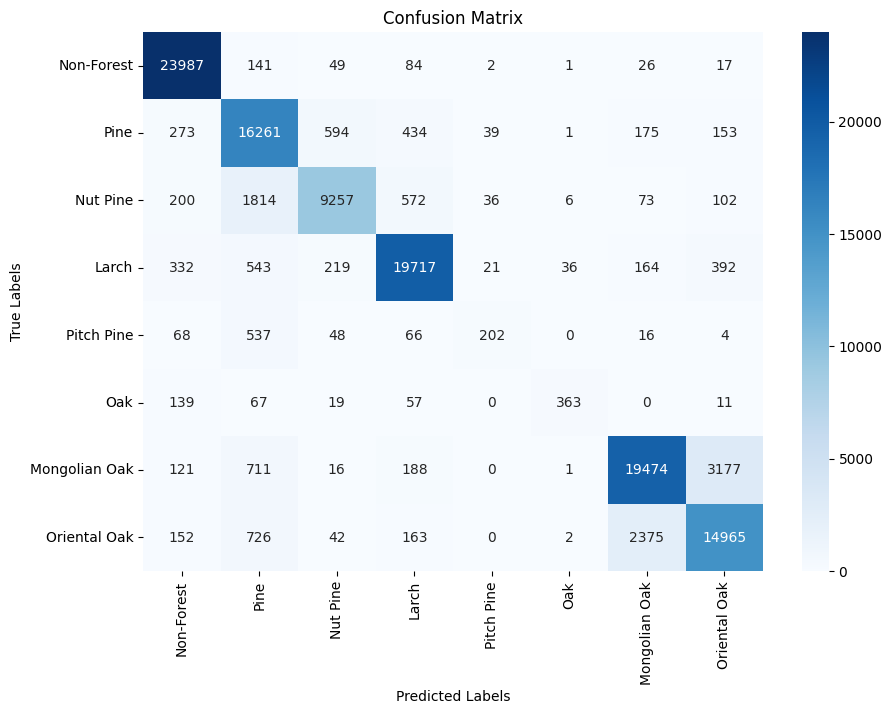

Classification Report:
               precision    recall  f1-score   support

   Non-Forest      0.949     0.987     0.968     24307
         Pine      0.782     0.907     0.840     17930
     Nut Pine      0.904     0.768     0.830     12060
        Larch      0.927     0.920     0.923     21424
   Pitch Pine      0.673     0.215     0.326       941
          Oak      0.885     0.553     0.681       656
Mongolian Oak      0.873     0.822     0.847     23688
 Oriental Oak      0.795     0.812     0.804     18425

     accuracy                          0.873    119431
    macro avg      0.849     0.748     0.777    119431
 weighted avg      0.874     0.873     0.871    119431



In [34]:
evaluate_model_with_cm(model, train_loader, num_classes=8)

Evaluation Progress: 100%|██████████| 1169/1169 [00:38<00:00, 30.50it/s]


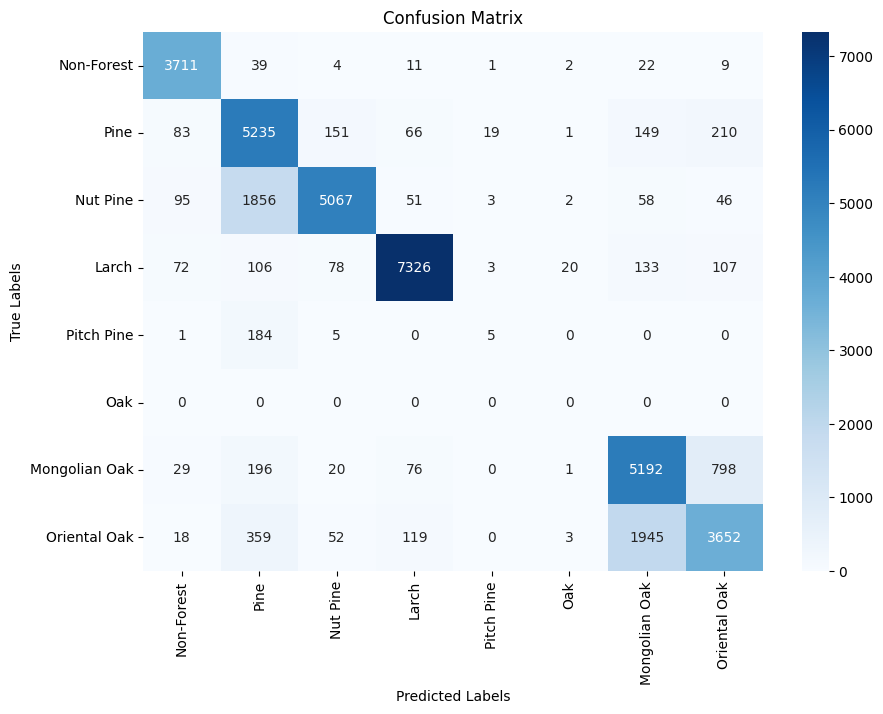

Classification Report:
               precision    recall  f1-score   support

   Non-Forest      0.926     0.977     0.951      3799
         Pine      0.656     0.885     0.754      5914
     Nut Pine      0.942     0.706     0.807      7178
        Larch      0.958     0.934     0.946      7845
   Pitch Pine      0.161     0.026     0.044       195
          Oak      0.000     0.000     0.000         0
Mongolian Oak      0.692     0.823     0.752      6312
 Oriental Oak      0.757     0.594     0.666      6148

     accuracy                          0.807     37391
    macro avg      0.637     0.618     0.615     37391
 weighted avg      0.822     0.807     0.806     37391



c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [35]:
evaluate_model_with_cm(model, val_loader, num_classes=8)